<a href="https://colab.research.google.com/github/funghunlung-star/sound/blob/main/Copy_of_Sound.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

File loaded successfully!
Sample rate : 44100 Hz
Duration    : 10.00 s
Total samples: 441000


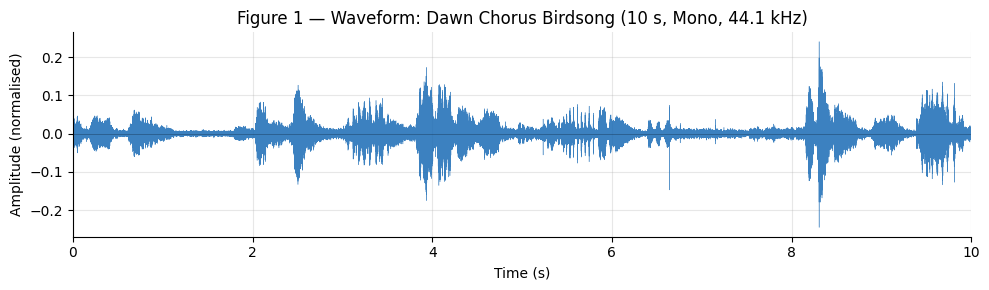

Figure 1 saved as fig1_waveform.png


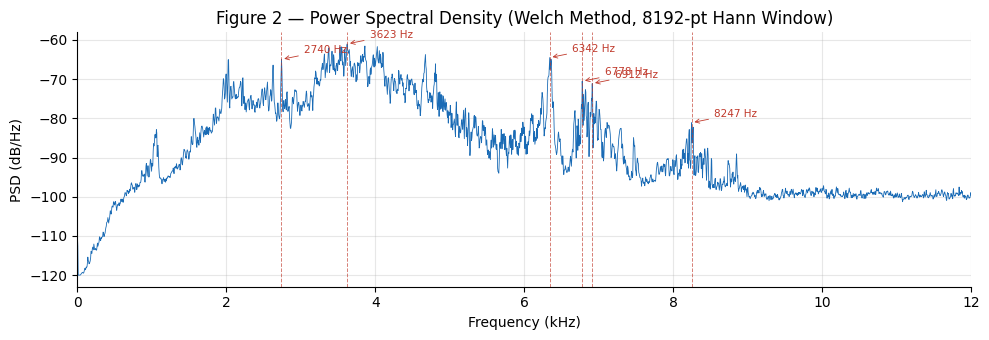

Figure 2 saved as fig2_spectrum.png


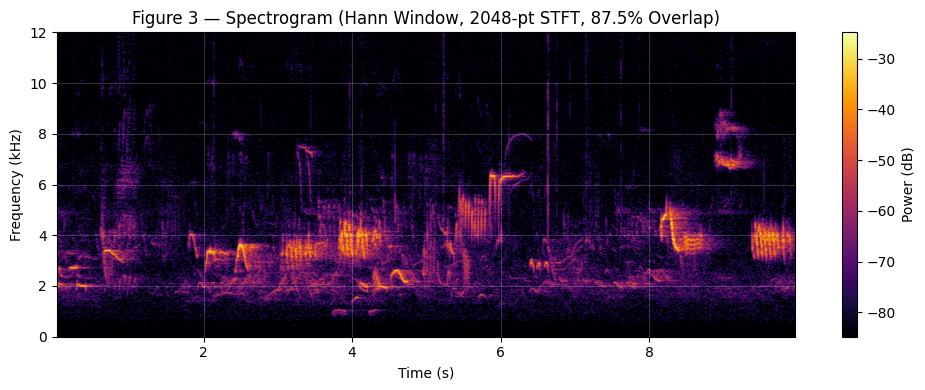

Figure 3 saved as fig3_spectrogram.png

========== FEATURE EXTRACTION RESULTS ==========
  Mean amplitude        : -0.00000009
  Std deviation         : 0.019906
  RMS amplitude         : 0.019906
  Peak amplitude        : 0.245071
  Crest factor          : 12.3113
  Spectral centroid     : 3859.2 Hz
  Spectral rolloff (85%): 4478.9 Hz
  Zero-crossing rate    : 0.197372 per sample

  Top spectral peaks:
    Rank 1: 3623 Hz  |  -61.0 dB  |  prominence = 38.95
    Rank 2: 6342 Hz  |  -64.5 dB  |  prominence = 29.47
    Rank 3: 6778 Hz  |  -70.5 dB  |  prominence = 23.79
    Rank 4: 6912 Hz  |  -71.1 dB  |  prominence = 18.63
    Rank 5: 2740 Hz  |  -65.0 dB  |  prominence = 17.60
    Rank 6: 8247 Hz  |  -81.1 dB  |  prominence = 16.19


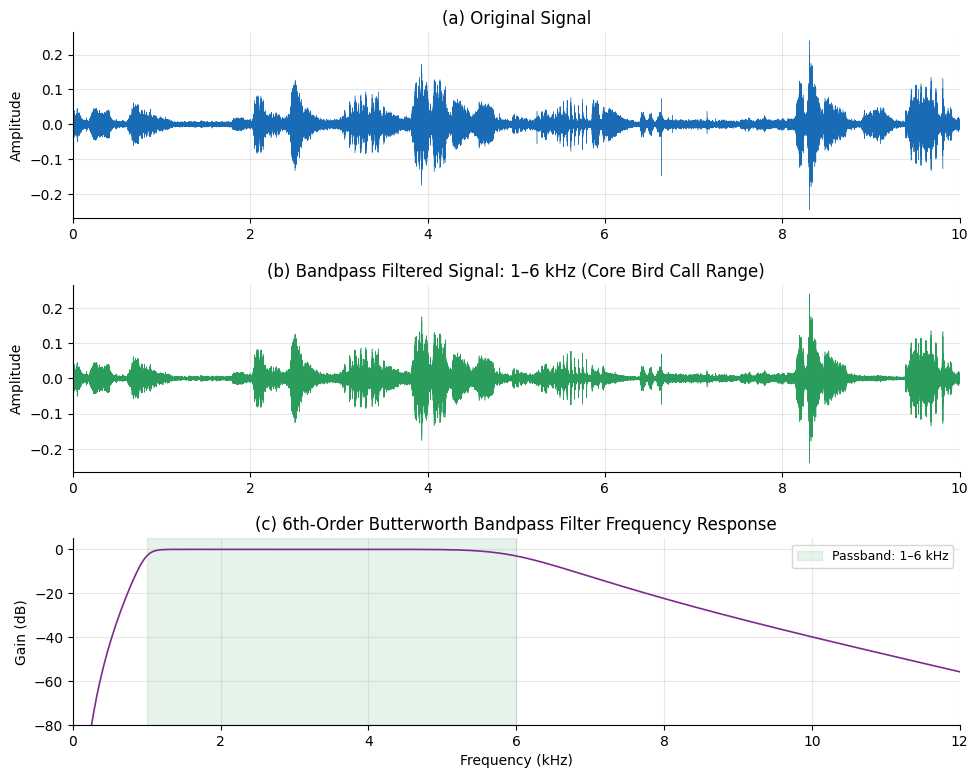

Figure 4 saved as fig4_filter.png

 All done! Download fig1–fig4 from the left sidebar.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.fft import fft, fftfreq
from scipy.signal import find_peaks
import wave

# ── LOAD AUDIO ────────────────────────────────────────────────────────
# Make sure the WAV file is uploaded to Colab first (left sidebar)
wf      = wave.open('/content/573080-squashy555-dawn-chorus-birdsong_R5mANEf3.wav')
fs      = wf.getframerate()          # sampling rate = 44,100 Hz
raw     = wf.readframes(wf.getnframes())
wf.close()

# Convert raw bytes to float64, stereo → mono by averaging both channels
samples = np.frombuffer(raw, dtype=np.int16).astype(np.float64)
samples = samples.reshape(-1, 2).mean(axis=1)   # merge stereo to mono
audio   = samples / 32768.0                      # normalise to [-1, 1]
t       = np.arange(len(audio)) / fs             # time axis in seconds
dur     = len(audio) / fs                        # total duration = 10.0 s

print(f"File loaded successfully!")
print(f"Sample rate : {fs} Hz")
print(f"Duration    : {dur:.2f} s")
print(f"Total samples: {len(audio)}")

# ─────────────────────────────────────────────────────────────────────
# FIGURE 1 — WAVEFORM (Time Domain)
# ─────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(t, audio, color='#1a6bb5', linewidth=0.3, alpha=0.85)
ax.set_xlim(0, dur)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Amplitude (normalised)')
ax.set_title('Figure 1 — Waveform: Dawn Chorus Birdsong (10 s, Mono, 44.1 kHz)')
ax.axhline(0, color='black', linewidth=0.4, alpha=0.4)
ax.grid(True, alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('fig1_waveform.png', dpi=150, bbox_inches='tight')  # saves to Colab
plt.show()
print("Figure 1 saved as fig1_waveform.png")

# ─────────────────────────────────────────────────────────────────────
# FIGURE 2 — FREQUENCY SPECTRUM
# Using Welch method instead of raw FFT:
# Welch averages multiple overlapping frames → smoother, more reliable
# spectrum for non-stationary signals like birdsong
# ─────────────────────────────────────────────────────────────────────
f_w, Pxx = signal.welch(audio, fs=fs,
                         nperseg=8192,    # window length (samples)
                         noverlap=4096,   # 50% overlap between frames
                         window='hann')   # Hann window reduces spectral leakage
Pxx_db = 10 * np.log10(Pxx + 1e-12)     # convert to dB

# Detect the most prominent spectral peaks in the 200–9000 Hz range
mask      = (f_w >= 200) & (f_w <= 9000)
peaks_idx, props = find_peaks(Pxx_db[mask],
                               height=Pxx_db[mask].max() - 30,
                               distance=20,
                               prominence=3)
xf_m      = f_w[mask]
top_peaks = sorted(zip(xf_m[peaks_idx],
                        Pxx_db[mask][peaks_idx],
                        props['prominences']),
                   key=lambda x: -x[2])[:6]   # top 6 peaks by prominence

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(f_w / 1000, Pxx_db, color='#1a6bb5', linewidth=0.6)
ax.set_xlim(0, 12)
ax.set_xlabel('Frequency (kHz)')
ax.set_ylabel('PSD (dB/Hz)')
ax.set_title('Figure 2 — Power Spectral Density (Welch Method, 8192-pt Hann Window)')
ax.grid(True, alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Annotate the top peaks on the plot
for freq, db, _ in top_peaks:
    ax.axvline(freq / 1000, color='#c0392b', linewidth=0.7, linestyle='--', alpha=0.65)
    ax.annotate(f'{freq:.0f} Hz',
                xy=(freq / 1000, db),
                xytext=(freq / 1000 + 0.3, db + 1.5),
                fontsize=7.5, color='#c0392b',
                arrowprops=dict(arrowstyle='->', color='#c0392b', lw=0.6))

plt.tight_layout()
plt.savefig('fig2_spectrum.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 2 saved as fig2_spectrum.png")

# ─────────────────────────────────────────────────────────────────────
# FIGURE 3 — SPECTROGRAM
# STFT using 2048-pt Hann window with 87.5% overlap
# Longer window → finer frequency resolution (~21.5 Hz per bin)
# High overlap → smoother time representation
# ─────────────────────────────────────────────────────────────────────
f_s, t_s, Sxx = signal.spectrogram(audio, fs=fs,
                                    nperseg=2048,    # window size
                                    noverlap=1792,   # 87.5% overlap
                                    window='hann',
                                    scaling='spectrum')
Sxx_db = 10 * np.log10(Sxx + 1e-12)

fig, ax = plt.subplots(figsize=(10, 4))
pcm = ax.pcolormesh(t_s, f_s / 1000, Sxx_db,
                    shading='gouraud',
                    cmap='inferno',
                    vmin=Sxx_db.max() - 60,   # dynamic range: 60 dB
                    vmax=Sxx_db.max())
plt.colorbar(pcm, ax=ax, label='Power (dB)')
ax.set_ylim(0, 12)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Frequency (kHz)')
ax.set_title('Figure 3 — Spectrogram (Hann Window, 2048-pt STFT, 87.5% Overlap)')
ax.grid(True, alpha=0.2, color='white')
plt.tight_layout()
plt.savefig('fig3_spectrogram.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 3 saved as fig3_spectrogram.png")

# ─────────────────────────────────────────────────────────────────────
# FEATURE EXTRACTION (no figure, print results)
# ─────────────────────────────────────────────────────────────────────
mean_amp = np.mean(audio)
std_amp  = np.std(audio)
rms      = np.sqrt(np.mean(audio**2))
peak     = np.max(np.abs(audio))
crest    = peak / rms                               # crest factor

# Spectral centroid: frequency-weighted mean of the PSD
sc       = np.sum(f_w * Pxx) / np.sum(Pxx)

# Spectral rolloff: frequency below which 85% of total energy falls
cumm     = np.cumsum(Pxx)
rolloff  = f_w[np.searchsorted(cumm, 0.85 * cumm[-1])]

# Zero-crossing rate: how often the signal changes sign per sample
zcr      = np.mean(np.abs(np.diff(np.sign(audio)))) / 2

print("\n========== FEATURE EXTRACTION RESULTS ==========")
print(f"  Mean amplitude        : {mean_amp:.8f}")
print(f"  Std deviation         : {std_amp:.6f}")
print(f"  RMS amplitude         : {rms:.6f}")
print(f"  Peak amplitude        : {peak:.6f}")
print(f"  Crest factor          : {crest:.4f}")
print(f"  Spectral centroid     : {sc:.1f} Hz")
print(f"  Spectral rolloff (85%): {rolloff:.1f} Hz")
print(f"  Zero-crossing rate    : {zcr:.6f} per sample")
print(f"\n  Top spectral peaks:")
for i, (freq, db, prom) in enumerate(top_peaks):
    print(f"    Rank {i+1}: {freq:.0f} Hz  |  {db:.1f} dB  |  prominence = {prom:.2f}")
print("=================================================")

# ─────────────────────────────────────────────────────────────────────
# FIGURE 4 — BANDPASS FILTER (isolate 1–6 kHz bird call range)
# 6th-order Butterworth: maximally flat passband, steep roll-off
# filtfilt applies filter twice (forward + backward) = zero phase shift
# ─────────────────────────────────────────────────────────────────────
b, a     = signal.butter(6, [1000 / (fs/2), 6000 / (fs/2)], btype='band')
audio_bp = signal.filtfilt(b, a, audio)    # zero-phase filtering

# Filter frequency response
w, h = signal.freqz(b, a, worN=8192, fs=fs)

fig, axes = plt.subplots(3, 1, figsize=(10, 8))

# Panel (a): Original signal
axes[0].plot(t, audio, color='#1a6bb5', linewidth=0.3)
axes[0].set_xlim(0, dur)
axes[0].set_ylabel('Amplitude')
axes[0].set_title('(a) Original Signal')
axes[0].grid(True, alpha=0.3)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Panel (b): Filtered signal — only 1–6 kHz remains
axes[1].plot(t, audio_bp, color='#2a9d5c', linewidth=0.4)
axes[1].set_xlim(0, dur)
axes[1].set_ylabel('Amplitude')
axes[1].set_title('(b) Bandpass Filtered Signal: 1–6 kHz (Core Bird Call Range)')
axes[1].grid(True, alpha=0.3)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

# Panel (c): Filter frequency response
axes[2].plot(w / 1000, 20 * np.log10(np.abs(h) + 1e-12), color='#7b2d8b', linewidth=1.2)
axes[2].axvspan(1, 6, alpha=0.12, color='#2a9d5c', label='Passband: 1–6 kHz')
axes[2].set_xlim(0, 12)
axes[2].set_ylim(-80, 5)
axes[2].set_xlabel('Frequency (kHz)')
axes[2].set_ylabel('Gain (dB)')
axes[2].set_title('(c) 6th-Order Butterworth Bandpass Filter Frequency Response')
axes[2].legend(fontsize=9)
axes[2].grid(True, alpha=0.3)
axes[2].spines['top'].set_visible(False)
axes[2].spines['right'].set_visible(False)

plt.tight_layout(pad=1.5)
plt.savefig('fig4_filter.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 4 saved as fig4_filter.png")

print("\n All done! Download fig1–fig4 from the left sidebar.")